# MuonPackedCandMatch workbook

This workbook reads the validation ntuples produced by `MuonPackedCandMatchNtuplizer` and focuses on the comparison of the legacy, vector, chi2, dz-selected-PV, dz-associated-PV, and pointer-based matching views.

The ntuple trees live under the ROOT directory `muonPackedCandMatch`, so the paths used here are:

- `muonPackedCandMatch/Events`
- `muonPackedCandMatch/MuonCandMatch`


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [2]:
TREE_DIR = "muonPackedCandMatch"
EVENTS_TREE = f"{TREE_DIR}/Events"
CAND_TREE = f"{TREE_DIR}/MuonCandMatch"

DATA_PATH = Path("/eos/user/c/chiw/JpsiJpsiPhi/CMSSW_15_0_15_JpsiJpsiPhi_refactor/src/test_muonPackedMatch_dataRun2023D_softId_v2.root")
MC_PATH = Path("/eos/user/c/chiw/JpsiJpsiPhi/CMSSW_15_0_15_JpsiJpsiPhi_refactor/src/test_muonPackedMatch_mcRun2022_softId_v2_numEvent2000.root")

SAMPLES = {
    "data": DATA_PATH,
    "mc": MC_PATH,
}

METHODS = {
    "legacy": {"winner": "mu_matchLegacyPackedIdx", "pass": "legacyBoxPass", "final": "finalLegacy"},
    "vector": {"winner": "mu_matchVectorPackedIdx", "pass": "vectorPass", "final": "finalVector"},
    "chi2": {"winner": "mu_matchChi2PackedIdx", "pass": "chi2Pass", "final": "finalChi2"},
    "dzPv": {"winner": "mu_matchDzPvPackedIdx", "pass": "dzPvPass", "final": "finalDzPv"},
    "dzAssoc": {"winner": "mu_matchDzAssocPackedIdx", "pass": "dzAssocPass", "final": "finalDzAssoc"},
    "pointer": {"winner": "mu_matchPointerPackedIdx", "pass": "pointerMatchAny", "final": "finalPointer"},
}


In [3]:
def open_ntuple(path):
    root_file = uproot.open(path)
    events = root_file[EVENTS_TREE].arrays(library="ak")
    candidates = root_file[CAND_TREE].arrays(library="ak")
    return events, candidates


def flatten_muons(events):
    template = events["mu_index"]
    run, lumi, event, selected_pv, _= ak.broadcast_arrays(
        events["run"],
        events["lumi"],
        events["event"],
        events["selectedPVIndex"],
        template,
    )

    table = {
        "run": ak.to_numpy(ak.flatten(run)),
        "lumi": ak.to_numpy(ak.flatten(lumi)),
        "event": ak.to_numpy(ak.flatten(event)),
        "selectedPVIndex": ak.to_numpy(ak.flatten(selected_pv)),
    }

    for field in events.fields:
        if field.startswith("mu_"):
            table[field] = ak.to_numpy(ak.flatten(events[field]))

    return pd.DataFrame(table)


def flatten_candidates(candidates):
    return pd.DataFrame({field: ak.to_numpy(candidates[field]) for field in candidates.fields})


def load_tables(path):
    events, candidates = open_ntuple(path)
    return {
        "events": events,
        "candidates": candidates,
        "muons": flatten_muons(events),
        "cand_df": flatten_candidates(candidates),
    }


In [4]:
sample_tables = {name: load_tables(path) for name, path in SAMPLES.items()}
for name, tables in sample_tables.items():
    print(name)
    print("  muon rows   :", len(tables["muons"]))
    print("  candidate rows:", len(tables["cand_df"]))
    print("  event branches:", list(tables["events"].fields))
    print("  candidate branches:", list(tables["candidates"].fields))


data
  muon rows   : 61706
  candidate rows: 120044
  event branches: ['run', 'lumi', 'event', 'selectedPVIndex', 'nPV', 'nSlimmedMuons', 'nMuStored', 'pv_x', 'pv_y', 'pv_z', 'pv_xErr', 'pv_yErr', 'pv_zErr', 'pv_chi2', 'pv_ndof', 'pv_sumPt2', 'pv_nTracks', 'pv_isValid', 'mu_index', 'mu_passSelection', 'mu_charge', 'mu_hasTrack', 'mu_trackSource', 'mu_pt', 'mu_eta', 'mu_phi', 'mu_px', 'mu_py', 'mu_pz', 'mu_ptErr', 'mu_etaErr', 'mu_phiErr', 'mu_dxyErr', 'mu_dzErr', 'mu_pxErr', 'mu_pyErr', 'mu_pzErr', 'mu_dzSelectedPV', 'mu_dxySelectedPV', 'mu_passedCutBasedIdLoose', 'mu_passedCutBasedIdMedium', 'mu_passedCutBasedIdMediumPrompt', 'mu_passedCutBasedIdTight', 'mu_passedCutBasedIdGlobalHighPt', 'mu_passedCutBasedIdTrkHighPt', 'mu_passedCutBasedIdSoft', 'mu_passedMvaIDwpSoft', 'mu_mvaIDValue', 'mu_passedMvaIDwpMedium', 'mu_passedMvaIDwpTight', 'mu_nSourceCandidatePtrs', 'mu_hasPfCandidateRef', 'mu_pfCandidateRefResolved', 'mu_sourceCandidateResolvedCount', 'mu_pointerResolvedCount', 'mu_point

## Muon-level and candidate-level helper summaries

The `Events` tree is ideal for winner-level summaries because it already stores one winner index per method for every muon. The `MuonCandMatch` tree is used for per-method candidate multiplicities and for attaching winner metadata such as `cand_fromPV`, `cand_pvAssocQuality`, and `cand_pdgId`.


In [5]:
MUON_KEY = ["run", "lumi", "event", "mu_index"]
CAND_KEY = ["run", "lumi", "event", "muonIndex", "packedIndex"]


def candidate_multiplicity(cand_df):
    base = cand_df[["run", "lumi", "event", "muonIndex"]].drop_duplicates().copy()
    for method, cols in METHODS.items():
        counts = (
            cand_df.groupby(["run", "lumi", "event", "muonIndex"])[cols["pass"]]
            .sum()
            .rename(f"n_{method}_pass")
            .reset_index()
        )
        base = base.merge(counts, on=["run", "lumi", "event", "muonIndex"], how="left")
    return base.fillna(0)


def match_category(counts):
    if counts == 0:
        return "no-match"
    if counts == 1:
        return "unique"
    return "multi"


def multiplicity_category_table(cand_df):
    counts = candidate_multiplicity(cand_df)
    for method in METHODS:
        counts[f"cat_{method}"] = counts[f"n_{method}_pass"].map(match_category)
    return counts


def agreement_matrix(mu_df):
    columns = {name: meta["winner"] for name, meta in METHODS.items()}
    out = pd.DataFrame(index=columns.keys(), columns=columns.keys(), dtype=float)
    for left_name, left_col in columns.items():
        for right_name, right_col in columns.items():
            valid = (mu_df[left_col] >= 0) & (mu_df[right_col] >= 0)
            if valid.sum() == 0:
                out.loc[left_name, right_name] = np.nan
            else:
                out.loc[left_name, right_name] = (mu_df.loc[valid, left_col] == mu_df.loc[valid, right_col]).mean()
    return out


In [6]:
for sample_name, tables in sample_tables.items():
    counts = multiplicity_category_table(tables["cand_df"])
    print(f"\nSample: {sample_name}")
    for method in METHODS:
        summary = counts[f"cat_{method}"].value_counts().reindex(["no-match", "unique", "multi"], fill_value=0)
        print(method)
        print(summary)



Sample: data
legacy
cat_legacy
no-match      202
unique      57655
multi        2373
Name: count, dtype: int64
vector
cat_vector
no-match      287
unique      59930
multi          13
Name: count, dtype: int64
chi2
cat_chi2
no-match       52
unique      59397
multi         781
Name: count, dtype: int64
dzPv
cat_dzPv
no-match      129
unique      59879
multi         222
Name: count, dtype: int64
dzAssoc
cat_dzAssoc
no-match      128
unique      59880
multi         222
Name: count, dtype: int64
pointer
cat_pointer
no-match      291
unique      59939
multi           0
Name: count, dtype: int64

Sample: mc
legacy
cat_legacy
no-match      40
unique      5576
multi        161
Name: count, dtype: int64
vector
cat_vector
no-match      39
unique      5737
multi          1
Name: count, dtype: int64
chi2
cat_chi2
no-match       0
unique      5719
multi         58
Name: count, dtype: int64
dzPv
cat_dzPv
no-match       5
unique      5754
multi         18
Name: count, dtype: int64
dzAssoc
cat_dzAsso

/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-4b3f1d182846dd5b8cdd065bebf4e7f2/lib/python3.9/site-packages/numpy/core/getlimits.py:518: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/cvmfs/cms.cern.ch/el9_amd64_gcc12/external/py3-numpy/1.24.3-4b3f1d182846dd5b8cdd065bebf4e7f2/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


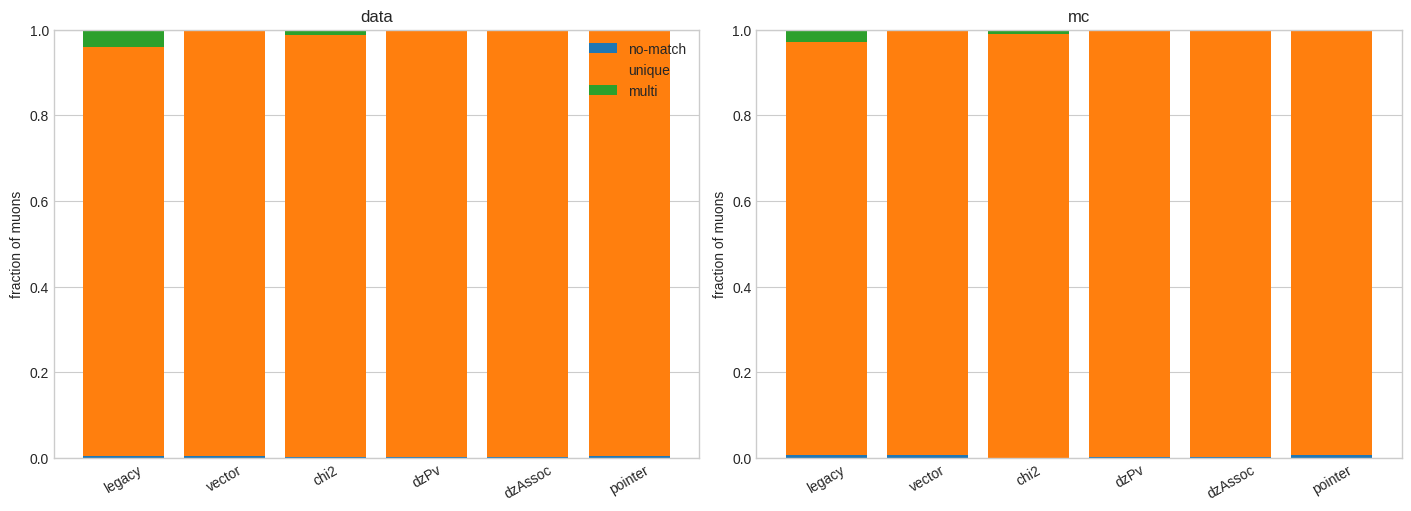

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, (sample_name, tables) in zip(axes, sample_tables.items()):
    counts = multiplicity_category_table(tables["cand_df"])
    fractions = []
    labels = []
    for method in METHODS:
        summary = counts[f"cat_{method}"].value_counts(normalize=True).reindex(["no-match", "unique", "multi"], fill_value=0.0)
        fractions.append(summary.to_numpy())
        labels.append(method)
    values = np.asarray(fractions)
    x = np.arange(len(labels))
    ax.bar(x, values[:, 0], label="no-match")
    ax.bar(x, values[:, 1], bottom=values[:, 0], label="unique")
    ax.bar(x, values[:, 2], bottom=values[:, 0] + values[:, 1], label="multi")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_ylim(0, 1)
    ax.set_title(sample_name)
    ax.set_ylabel("fraction of muons")
axes[0].legend()
plt.show()


In [8]:
for sample_name, tables in sample_tables.items():
    matrix = agreement_matrix(tables["muons"])
    print(f"\nAgreement matrix for {sample_name}")
    display(matrix)



Agreement matrix for data


,legacy,vector,chi2,dzPv,dzAssoc,pointer
legacy,1.000000,0.979244,0.979255,0.979230,0.979230,0.979241
vector,0.979244,1.000000,1.000000,1.000000,1.000000,1.000000
chi2,0.979255,1.000000,1.000000,0.999251,0.999235,1.000000
dzPv,0.979230,1.000000,0.999251,1.000000,0.999967,1.000000
dzAssoc,0.979230,1.000000,0.999235,0.999967,1.000000,1.000000
pointer,0.979241,1.000000,1.000000,1.000000,1.000000,1.000000



Agreement matrix for mc


,legacy,vector,chi2,dzPv,dzAssoc,pointer
legacy,1.000000,0.986043,0.986048,0.986043,0.986043,0.986041
vector,0.986043,1.000000,1.000000,1.000000,1.000000,1.000000
chi2,0.986048,1.000000,1.000000,0.999307,0.999307,1.000000
dzPv,0.986043,1.000000,0.999307,1.000000,0.999827,1.000000
dzAssoc,0.986043,1.000000,0.999307,0.999827,1.000000,1.000000
pointer,0.986041,1.000000,1.000000,1.000000,1.000000,1.000000


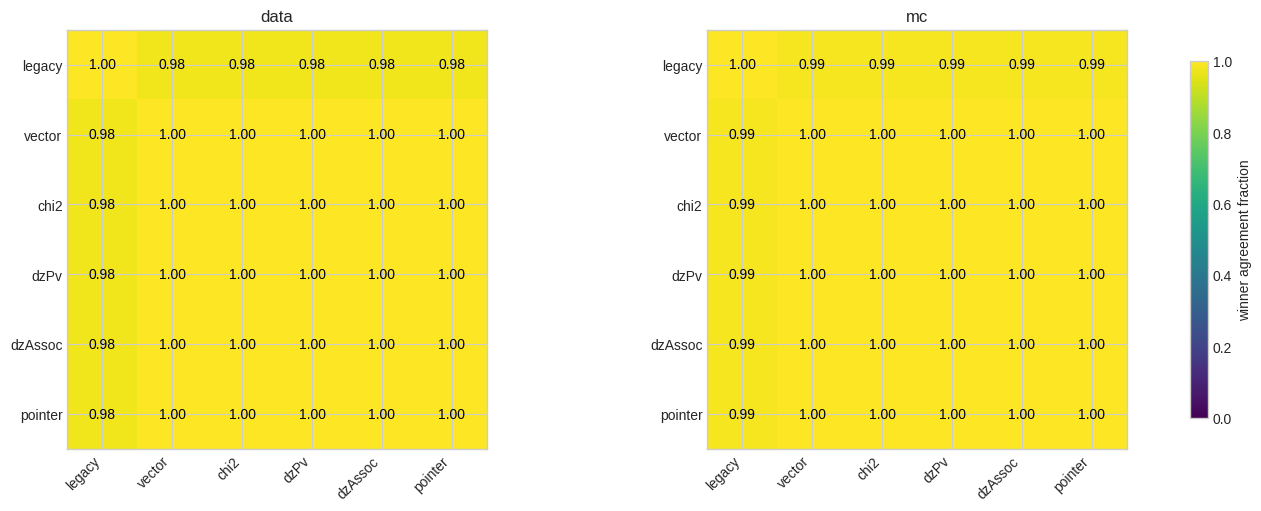

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, (sample_name, tables) in zip(axes, sample_tables.items()):
    matrix = agreement_matrix(tables["muons"])
    image = ax.imshow(matrix.to_numpy(dtype=float), vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_title(sample_name)
    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            value = matrix.iloc[i, j]
            label = "nan" if pd.isna(value) else f"{value:.2f}"
            ax.text(j, i, label, ha="center", va="center", color="white" if not pd.isna(value) and value < 0.6 else "black")
fig.colorbar(image, ax=axes.ravel().tolist(), shrink=0.85, label="winner agreement fraction")
plt.show()


## Pointer diagnostics

The event tree already records how many PAT pointers resolved for each muon. The next cells summarize pointer-resolved and multiplicity-anomaly categories.


In [10]:
for sample_name, tables in sample_tables.items():
    mu_df = tables["muons"]
    summary = pd.DataFrame({
        "pointer_resolved": (mu_df["mu_pointerResolvedCount"] > 0).value_counts(),
        "multiplicity_anomaly": (mu_df["mu_pointerMultiplicityAnomaly"] > 0).value_counts(),
    }).fillna(0).astype(int)
    print(f"\nPointer summary for {sample_name}")
    display(summary)



Pointer summary for data


,pointer_resolved,multiplicity_anomaly
False,1767,61706
True,59939,0



Pointer summary for mc


,pointer_resolved,multiplicity_anomaly
False,279,6015
True,5736,0


In [11]:
def attach_winner_metadata(mu_df, cand_df, method_name):
    winner_col = METHODS[method_name]["winner"]
    merge_left = mu_df[["run", "lumi", "event", "mu_index", winner_col]].copy()
    merge_left = merge_left.rename(columns={"mu_index": "muonIndex", winner_col: "packedIndex"})
    merge_left = merge_left[merge_left["packedIndex"] >= 0]
    keep_cols = [
        "run", "lumi", "event", "muonIndex", "packedIndex",
        "cand_fromPV", "cand_pvAssocQuality", "cand_vertexRefKey", "cand_pdgId",
        "pointerMatchAny", "pointerMatchSource", "pointerMatchPfRef",
    ]
    merged = merge_left.merge(cand_df[keep_cols], on=["run", "lumi", "event", "muonIndex", "packedIndex"], how="left")
    merged["method"] = method_name
    return merged


def collect_winner_metadata(tables):
    mu_df = tables["muons"]
    cand_df = tables["cand_df"]
    frames = [attach_winner_metadata(mu_df, cand_df, method_name) for method_name in METHODS]
    return pd.concat(frames, ignore_index=True)


In [12]:
winner_tables = {name: collect_winner_metadata(tables) for name, tables in sample_tables.items()}
for sample_name, winners in winner_tables.items():
    print(f"\nWinner metadata preview for {sample_name}")
    display(winners.head())



Winner metadata preview for data


,run,lumi,event,muonIndex,packedIndex,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,cand_pdgId,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,method
0,369873,1,446440,0,1023,2,4,3,-13,1,1,0,legacy
1,369873,1,446440,1,965,2,7,1,13,1,1,0,legacy
2,369873,1,446440,2,981,2,5,2,-13,1,1,0,legacy
3,369873,1,446440,3,895,3,7,0,-211,0,0,0,legacy
4,369873,1,446440,4,397,2,7,5,-13,1,1,0,legacy



Winner metadata preview for mc


,run,lumi,event,muonIndex,packedIndex,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,cand_pdgId,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,method
0,1,1,2,0,777,3,7,0,-13,1,1,0,legacy
1,1,1,2,1,786,3,7,0,13,1,1,0,legacy
2,1,1,2,2,787,3,7,0,13,1,1,0,legacy
3,1,1,2,3,791,3,7,0,13,1,1,0,legacy
4,1,1,2,4,928,2,7,8,13,1,1,0,legacy


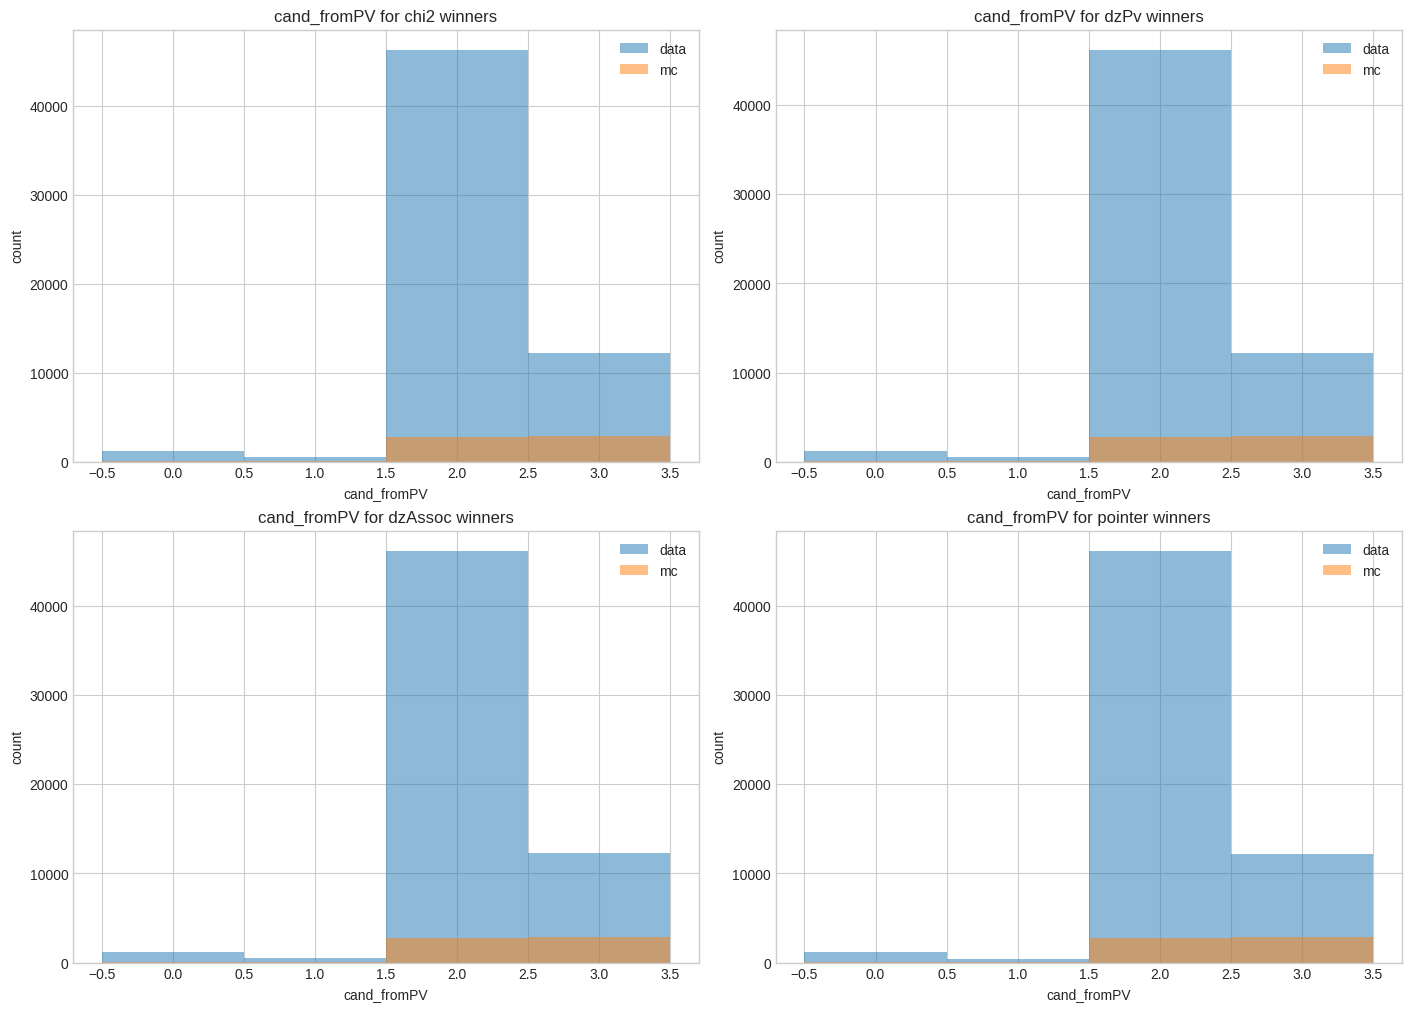

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
plot_methods = ["chi2", "dzPv", "dzAssoc", "pointer"]
for ax, method_name in zip(axes.ravel(), plot_methods):
    for sample_name, winners in winner_tables.items():
        subset = winners[winners["method"] == method_name]
        values = subset["cand_fromPV"].dropna().to_numpy()
        bins = np.arange(values.min() - 0.5, values.max() + 1.5) if len(values) else np.arange(-0.5, 4.5)
        ax.hist(values, bins=bins, alpha=0.5, label=sample_name)
    ax.set_title(f"cand_fromPV for {method_name} winners")
    ax.set_xlabel("cand_fromPV")
    ax.set_ylabel("count")
    ax.legend()
plt.show()


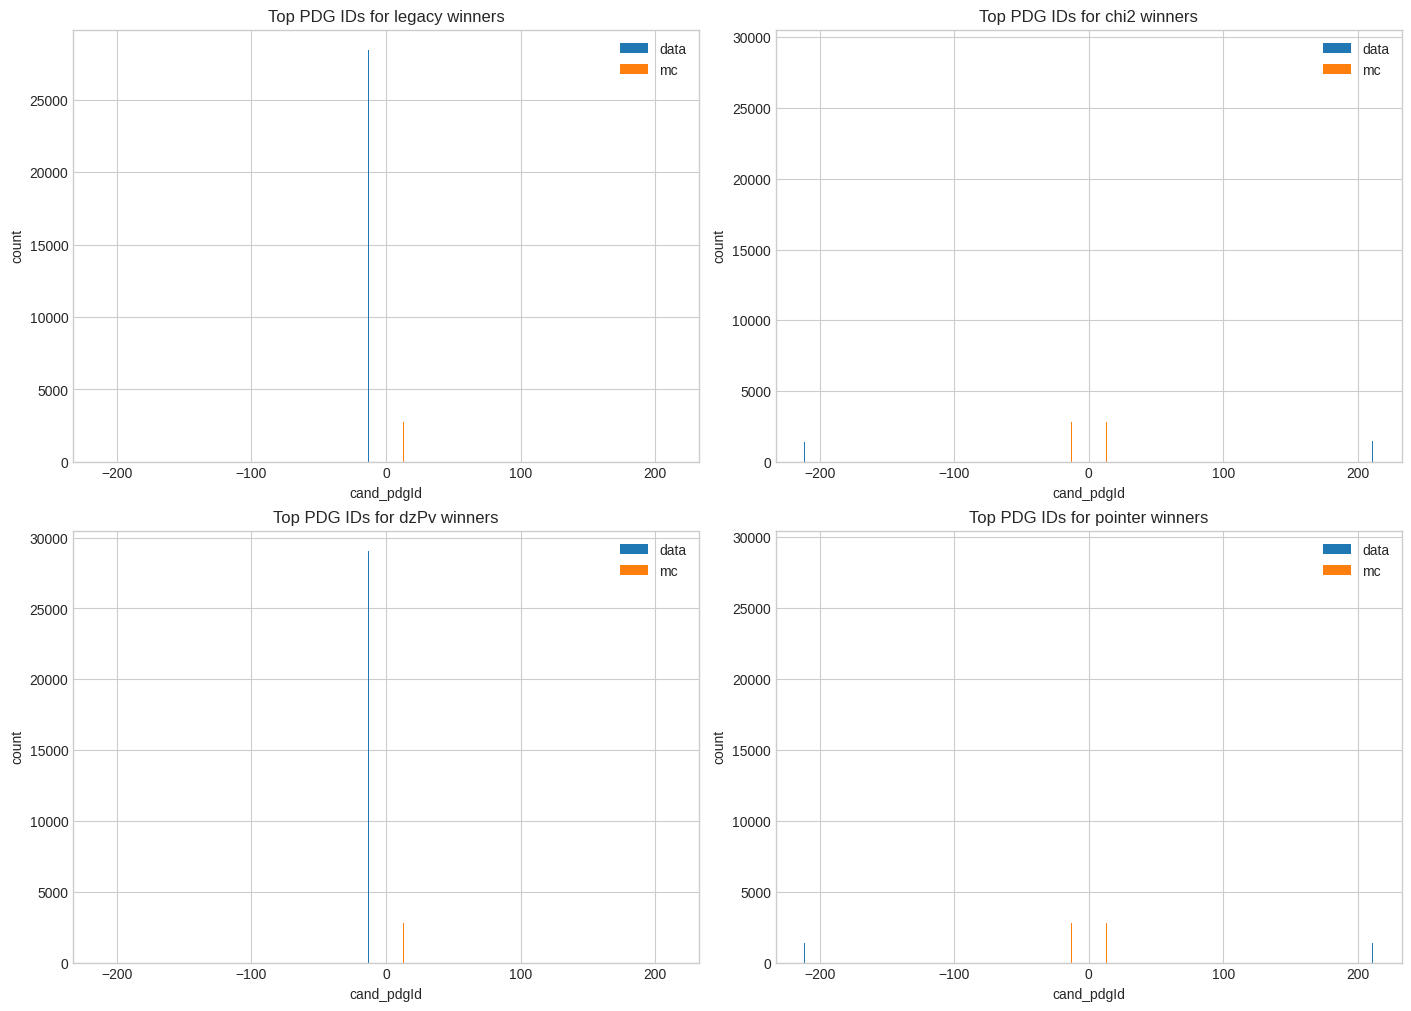

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
plot_methods = ["legacy", "chi2", "dzPv", "pointer"]
for ax, method_name in zip(axes.ravel(), plot_methods):
    for sample_name, winners in winner_tables.items():
        subset = winners[winners["method"] == method_name]
        values = subset["cand_pdgId"].dropna().to_numpy()
        if len(values) == 0:
            continue
        unique, counts = np.unique(values, return_counts=True)
        order = np.argsort(counts)[::-1][:10]
        ax.bar(unique[order] + (0.15 if sample_name == "mc" else -0.15), counts[order], width=0.3, label=sample_name)
    ax.set_title(f"Top PDG IDs for {method_name} winners")
    ax.set_xlabel("cand_pdgId")
    ax.set_ylabel("count")
    ax.legend()
plt.show()


## Focused disagreement studies

These selections are useful for the cases highlighted in the original validation plan.

- `legacy != chi2`
- `chi2 != dzPv`
- `chi2 != dzAssoc`
- pointer-resolved vs pointer-unresolved


In [15]:
def disagreement_table(mu_df):
    out = mu_df.copy()
    out["legacy_vs_chi2"] = out["mu_matchLegacyPackedIdx"] != out["mu_matchChi2PackedIdx"]
    out["chi2_vs_dzPv"] = out["mu_matchChi2PackedIdx"] != out["mu_matchDzPvPackedIdx"]
    out["chi2_vs_dzAssoc"] = out["mu_matchChi2PackedIdx"] != out["mu_matchDzAssocPackedIdx"]
    out["pointer_resolved"] = out["mu_pointerResolvedCount"] > 0
    return out

for sample_name, tables in sample_tables.items():
    diff = disagreement_table(tables["muons"])
    print(f"\nDisagreement summary for {sample_name}")
    display(diff[["legacy_vs_chi2", "chi2_vs_dzPv", "chi2_vs_dzAssoc", "pointer_resolved"]].mean().rename("fraction"))



Disagreement summary for data


legacy_vs_chi2      0.024876
chi2_vs_dzPv        0.001977
chi2_vs_dzAssoc     0.001977
pointer_resolved    0.971364
Name: fraction, dtype: float64


Disagreement summary for mc


legacy_vs_chi2      0.020449
chi2_vs_dzPv        0.001496
chi2_vs_dzAssoc     0.001496
pointer_resolved    0.953616
Name: fraction, dtype: float64

In [16]:
for sample_name, tables in sample_tables.items():
    diff = disagreement_table(tables["muons"])
    subset = diff.loc[diff["legacy_vs_chi2"] | diff["chi2_vs_dzPv"] | diff["chi2_vs_dzAssoc"]]
    print(f"\nDetailed disagreement rows for {sample_name}")
    display(subset[[
        "run", "lumi", "event", "mu_index",
        # Muon quality and kinematics
        "mu_pt", "mu_ptErr",
        "mu_eta", "mu_etaErr",
        "mu_phi", "mu_phiErr",
        "mu_passedCutBasedIdLoose",
        "mu_passedCutBasedIdMedium",
        "mu_passedCutBasedIdGlobalHighPt",
        # Muon match results
        "mu_matchLegacyPackedIdx", "mu_matchChi2PackedIdx", "mu_matchDzPvPackedIdx", "mu_matchDzAssocPackedIdx",
        "mu_pointerResolvedCount", "mu_pointerMultiplicityAnomaly"
    ]].head(20))



Detailed disagreement rows for data


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdGlobalHighPt,mu_matchLegacyPackedIdx,mu_matchChi2PackedIdx,mu_matchDzPvPackedIdx,mu_matchDzAssocPackedIdx,mu_pointerResolvedCount,mu_pointerMultiplicityAnomaly
3,369873,1,446440,3,1.279996,0.035285,2.210458,0.002785,-0.207946,0.003063,1,0,0,895,1044,1044,1044,1,0
18,369873,1,543928,4,2.141543,0.042373,-2.230198,0.001725,-1.252387,0.001897,1,0,0,1362,1518,1518,1518,1,0
58,369873,1,499624,0,8.987274,2.417534,1.203886,0.018641,-2.357270,0.077836,0,0,0,-1,1200,1200,1200,0,0
59,369873,1,499624,1,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,0,0,0,-1,1258,11,11,0,0
131,369873,1,152672,2,0.968245,0.024030,2.268646,0.005075,2.377690,0.005576,1,1,0,964,1272,1272,1272,1,0
134,369873,1,176360,2,1.514504,0.036323,2.420250,0.002686,2.959257,0.002863,1,1,0,930,1141,1141,1141,1,0
169,369873,1,112024,0,23.093943,1.271720,-1.570460,0.003407,3.077235,0.000815,0,0,0,-1,1275,-1,-1,0,0
182,369873,1,449472,0,11.252334,0.271034,-0.980750,0.001049,1.186972,0.000706,0,0,0,1400,1400,-1,-1,0,0
183,369873,1,449472,1,10.745840,0.136589,-0.966614,0.000313,1.196488,0.000331,1,1,0,-1,1400,1400,1400,1,0
245,369873,1,568432,2,1.329706,0.027886,1.942354,0.002422,-0.486307,0.002567,1,1,0,1423,1424,1424,1424,1,0



Detailed disagreement rows for mc


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdGlobalHighPt,mu_matchLegacyPackedIdx,mu_matchChi2PackedIdx,mu_matchDzPvPackedIdx,mu_matchDzAssocPackedIdx,mu_pointerResolvedCount,mu_pointerMultiplicityAnomaly
241,1,1,46,0,14.076769,5.472035,2.219539,0.074120,1.801988,0.019184,0,0,0,-1,689,689,689,0,0
258,1,1,40,3,4.635373,0.229068,-0.071735,0.028545,-2.292500,0.027790,0,0,0,-1,1017,1017,1017,0,0
286,1,1,48,5,1.261808,0.022800,2.301149,0.002950,-2.896966,0.003135,1,1,0,1428,1746,1746,1746,1,0
301,1,1,53,7,1.260800,0.044432,-2.168977,0.003994,-1.946282,0.006576,1,0,0,1206,1492,1492,1492,1,0
319,1,1,44,1,12.007483,17.872906,-2.053500,0.048514,0.105637,0.175871,0,0,0,-1,1022,1156,1156,0,0
328,1,1,58,3,1.713500,0.022765,-1.418476,0.001460,2.131720,0.001600,1,1,0,874,927,927,927,1,0
355,1,1,52,8,1.679233,0.047618,-2.227062,0.002179,2.284688,0.002366,1,0,0,1516,1705,1705,1705,1,0
383,1,1,67,4,0.986778,0.022297,2.053092,0.003401,0.830036,0.003607,1,0,0,739,1143,1143,1143,1,0
397,1,1,72,3,1.944679,0.049569,2.001705,0.001543,-2.858022,0.001947,1,0,0,908,909,909,909,1,0
432,1,1,69,4,1.023203,0.021842,2.071151,0.004614,-2.768322,0.005695,1,1,0,1099,1355,1355,1355,1,0


In [17]:
sample_name = "mc"
run_id = 1
lumi_id = 1
event_id = 27
mu_idx = 0

tables = sample_tables[sample_name]
mu_df = tables["muons"]
cand_df = tables["cand_df"]

mu_mask = (
    (mu_df["run"] == run_id)
    & (mu_df["lumi"] == lumi_id)
    & (mu_df["event"] == event_id)
    & (mu_df["mu_index"] == mu_idx)
)
mu_row = mu_df.loc[mu_mask].copy()

if mu_row.empty:
    print("Muon not found for requested (run, lumi, event, mu_index).")
else:
    mu_row = mu_row.iloc[0]

    # Winner indices by method for this muon
    winner_idx = {m: int(mu_row[meta["winner"]]) for m, meta in METHODS.items()}
    print("Winner packedIndex by method:")
    print(pd.Series(winner_idx, name="packedIndex"))

    # Compact muon view
    mu_cols = [
        "run", "lumi", "event", "mu_index","mu_charge"
        "mu_pt", "mu_ptErr"
        "mu_eta", "mu_etaErr",
        "mu_phi", "mu_phiErr",
        "mu_passSelection",
        "mu_pointerResolvedCount", "mu_pointerMultiplicityAnomaly",
        "mu_passedCutBasedIdLoose", "mu_passedCutBasedIdMedium",
        "mu_passedCutBasedIdTight", "mu_passedMvaIDwpMedium", "mu_passedMvaIDwpTight",
        "mu_mvaIDValue",
    ]
    mu_cols = [c for c in mu_cols if c in mu_df.columns]
    display(mu_row[mu_cols].to_frame("value"))

    # All related candidates
    cand_mask = (
        (cand_df["run"] == run_id)
        & (cand_df["lumi"] == lumi_id)
        & (cand_df["event"] == event_id)
        & (cand_df["muonIndex"] == mu_idx)
    )
    cands = cand_df.loc[cand_mask].copy()

    if cands.empty:
        print("No MuonCandMatch rows for this muon.")
    else:
        for method, idx in winner_idx.items():
            cands[f"isWinner_{method}"] = (cands["packedIndex"] == idx) if idx >= 0 else False

        cand_cols = [
            "packedIndex", "cand_pdgId", "cand_charge",
            "cand_pt", "cand_ptErr",
            "cand_eta", "cand_etaErr",
            "cand_phi", "cand_phiErr",
            "cand_fromPV", "cand_pvAssocQuality", "cand_vertexRefKey",
            "legacyBoxPass", "vectorPass", "chi2Pass", "dzPvPass", "dzAssocPass",
            "deltaPRelVec", "chi2MomentumDiag", "deltaDzSelectedPV", "deltaDzAssocPV",
            "chi2MomentumDzSelectedPV", "chi2MomentumDzAssocPV",
            "pointerMatchAny", "pointerMatchSource", "pointerMatchPfRef",
        ] + [f"isWinner_{m}" for m in METHODS]

        cand_cols = [c for c in cand_cols if c in cands.columns]
        sort_cols = [c for c in ["isWinner_legacy", "isWinner_vector", "isWinner_chi2", "isWinner_dzPv", "isWinner_dzAssoc", "isWinner_pointer", "packedIndex"] if c in cands.columns]
        ascending = [False] * (len(sort_cols) - 1) + [True] if len(sort_cols) > 0 else True

        display(cands.sort_values(sort_cols, ascending=ascending, kind="stable")[cand_cols])

Winner packedIndex by method:
legacy     1091
vector     1091
chi2       1091
dzPv       1091
dzAssoc    1091
pointer    1091
Name: packedIndex, dtype: int64


,value
run,1.000000
lumi,1.000000
event,27.000000
mu_index,0.000000
mu_etaErr,0.000281
mu_phi,2.053218
mu_phiErr,0.000358
mu_passSelection,1.000000
mu_pointerResolvedCount,1.000000
mu_pointerMultiplicityAnomaly,0.000000


,packedIndex,cand_pdgId,cand_charge,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,legacyBoxPass,vectorPass,chi2Pass,dzPvPass,dzAssocPass,deltaPRelVec,chi2MomentumDiag,deltaDzSelectedPV,deltaDzAssocPV,chi2MomentumDzSelectedPV,chi2MomentumDzAssocPV,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,isWinner_legacy,isWinner_vector,isWinner_chi2,isWinner_dzPv,isWinner_dzAssoc,isWinner_pointer
152,1091,13,-1,10.007812,0.147936,1.270974,0.000276,2.053189,0.000339,3,7,0,1,1,1,1,1,0.000181,0.000511,2.800953e-07,2.800774e-07,5.110190e-04,5.110190e-04,1,1,0,True,True,True,True,True,True
153,1260,13,-1,9.765625,0.295157,1.311258,0.001319,2.066078,0.000602,2,1,10,1,0,1,0,0,0.023929,5.793396,1.022621e+01,1.022567e+01,1.722123e+07,1.721943e+07,0,0,0,False,False,False,False,False,False


We ought to dive deeper into the mismatch occurences. Identify all mismatches and show all of the related candidates' properties

In [ ]:
mismatch_cand = []
for sample_name, tables in sample_tables.items():
    diff = disagreement_table(tables["muons"])
    subset = diff.loc[diff["legacy_vs_chi2"] | diff["chi2_vs_dzPv"] | diff["chi2_vs_dzAssoc"]]
    merged = subset.merge(
        tables["cand_df"],
        left_on=["run", "lumi", "event", "mu_index"],
        right_on=["run", "lumi", "event", "muonIndex"],
        how="left",
        suffixes=("", "_cand"),
    )
    merged["sample"] = sample_name
    mismatch_cand.append(merged)

In [19]:
# Take the following columns: cand_pdgId, cand_pt, cand_eta, cand_phi, pointerMatchAny, pointerMatchSource, pointerMatchPfRef
# Consider only muons with pT > 2 GeV
mismatch_cand_pT_filtered = []
for df in mismatch_cand:
    filtered = df[df["cand_pt"] > 2.0]
    mismatch_cand_pT_filtered.append(filtered[[
        "event", "mu_index", "mu_charge", "cand_pdgId",
        "mu_pt", "mu_ptErr",
        "mu_eta", "mu_etaErr",
        "mu_phi", "mu_phiErr",
        "cand_pt", "cand_ptErr",
        "cand_eta", "cand_etaErr",
        "cand_phi", "cand_phiErr",
        "vectorPass", "chi2MomentumDiag",
        "dzPvPass", "chi2MomentumDzSelectedPV",
        "dzAssocPass", "chi2MomentumDzAssocPV",
        "pointerMatchAny", "pointerMatchSource"
    ]])

In [20]:
mismatch_cand_pT_filtered[0].head(10)

,event,mu_index,mu_charge,cand_pdgId,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,vectorPass,chi2MomentumDiag,dzPvPass,chi2MomentumDzSelectedPV,dzAssocPass,chi2MomentumDzAssocPV,pointerMatchAny,pointerMatchSource
2,543928,4,-1,-211,2.141543,0.042373,-2.230198,0.001725,-1.252387,0.001897,2.453125,0.051470,-2.090762,0.001350,-1.335584,0.001404,0,122.268303,0,1093.403687,0,1094.942871,0,0
3,543928,4,-1,13,2.141543,0.042373,-2.230198,0.001725,-1.252387,0.001897,2.140625,0.042064,-2.230109,0.001705,-1.252387,0.001875,1,0.001548,1,0.001548,1,0.001548,1,1
4,499624,0,-1,-211,8.987274,2.417534,1.203886,0.018641,-2.357270,0.077836,2.291016,0.050517,2.333750,0.001693,-1.959431,0.001798,0,23.932350,1,24.136744,1,24.135990,0,0
552,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,4.792969,0.090024,1.221900,0.000552,2.736800,0.000592,0,3.822434,0,53.285202,0,53.285202,0,0
557,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.263672,0.016515,-0.036988,0.000965,-3.088078,0.000844,0,2.744263,0,52.211102,0,52.211102,0,0
559,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.740234,0.022242,-0.596026,0.000752,-2.516291,0.000774,0,3.776579,0,53.217884,0,53.217884,0,0
562,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.238281,0.054707,-2.282113,0.001627,-0.730682,0.001807,0,2.147028,0,51.673985,0,51.673985,0,0
563,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.103516,0.054002,-2.337046,0.001813,1.379823,0.002223,0,0.942846,0,50.247284,0,50.247284,0,0
574,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.683594,0.057956,0.709555,0.001004,2.945504,0.001069,0,2.765873,0,54.891731,0,54.885918,0,0
582,499624,1,1,211,6.919987,7.602214,-1.729300,0.078476,0.229564,0.122279,2.078125,0.017295,-0.561235,0.000909,0.662818,0.000969,0,1.156747,0,53.282513,0,53.275661,0,0


In [21]:
mismatch_cand_pT_filtered[1].head(10)

,event,mu_index,mu_charge,cand_pdgId,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,vectorPass,chi2MomentumDiag,dzPvPass,chi2MomentumDzSelectedPV,dzAssocPass,chi2MomentumDzAssocPV,pointerMatchAny,pointerMatchSource
280,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.804688,0.044858,-1.752190,0.003166,2.851165,0.002889,0,15.966223,1,15.968798,1,15.970423,0,0
281,46,0,-1,13,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,3.328125,0.069422,2.385388,0.001161,3.028898,0.001318,0,10.292673,1,10.418963,1,10.418963,0,0
285,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.570312,0.062690,1.095920,0.000876,1.735596,0.000991,0,17.267704,1,17.395428,1,17.395428,0,0
286,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.904297,0.023652,0.752403,0.000678,2.682989,0.000735,0,12.978077,1,13.106301,1,13.106301,0,0
287,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.013672,0.017683,0.681539,0.000921,2.252710,0.000948,0,15.517676,1,15.646025,1,15.646025,0,0
290,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,3.611328,0.027503,-0.295724,0.000787,1.571047,0.000610,0,19.445265,1,19.574703,1,19.574703,0,0
293,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,3.279297,0.037322,-0.966460,0.000725,2.902826,0.000873,0,14.658804,1,14.784958,1,14.784958,0,0
298,46,0,-1,13,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,3.759766,0.070099,-1.905820,0.000800,-2.302124,0.000895,0,21.113697,1,21.240484,1,21.240484,0,0
302,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.496094,0.027803,1.096835,0.000895,-1.924567,0.000916,0,20.217319,1,20.324928,1,20.325926,0,0
310,46,0,-1,-211,14.076769,5.472035,2.219539,0.07412,1.801988,0.019184,2.082031,0.027498,-1.655507,0.001364,3.008593,0.001356,0,16.533384,1,16.643520,1,16.643812,0,0


## Muon ID summaries

These cells summarize the MiniAOD-native `CutBasedId*` and prompt-`MvaId*` information stored on the muons. They are written to stay compatible with older ntuples that do not yet contain these branches.


In [22]:
MUON_CUTBASED_ID_COLUMNS = [
    "mu_passedCutBasedIdLoose",
    "mu_passedCutBasedIdMedium",
    "mu_passedCutBasedIdMediumPrompt",
    "mu_passedCutBasedIdTight",
    "mu_passedCutBasedIdGlobalHighPt",
    "mu_passedCutBasedIdTrkHighPt",
]

MUON_SOFT_ID_COLUMNS = [
    "mu_passedCutBasedIdSoft",
    "mu_passedMvaIDwpSoft",
]

MUON_MVA_ID_COLUMNS = [
    "mu_mvaIDValue",
    "mu_passedMvaIDwpMedium",
    "mu_passedMvaIDwpTight",
]

MUON_ID_WP_COLUMNS = MUON_CUTBASED_ID_COLUMNS + MUON_SOFT_ID_COLUMNS + MUON_MVA_ID_COLUMNS[1:]
MUON_ID_COLUMNS = MUON_CUTBASED_ID_COLUMNS + MUON_SOFT_ID_COLUMNS + MUON_MVA_ID_COLUMNS

BROWSE_SELECTIONS = {
    "legacy": {
        "count_col": "mu_nPassLegacyBox",
        "pass_col": "legacyBoxPass",
        "final_col": "finalLegacy",
        "winner_col": "mu_matchLegacyPackedIdx",
        "sort_metric": "deltaPRelVec",
    },
    "vector": {
        "count_col": "mu_nPassVector",
        "pass_col": "vectorPass",
        "final_col": "finalVector",
        "winner_col": "mu_matchVectorPackedIdx",
        "sort_metric": "deltaPRelVec",
    },
    "chi2": {
        "count_col": "mu_nPassChi2",
        "pass_col": "chi2Pass",
        "final_col": "finalChi2",
        "winner_col": "mu_matchChi2PackedIdx",
        "sort_metric": "chi2MomentumDiag",
    },
    "dzPv": {
        "count_col": "mu_nPassDzPv",
        "pass_col": "dzPvPass",
        "final_col": "finalDzPv",
        "winner_col": "mu_matchDzPvPackedIdx",
        "sort_metric": "chi2MomentumDzSelectedPV",
    },
    "dzAssoc": {
        "count_col": "mu_nPassDzAssoc",
        "pass_col": "dzAssocPass",
        "final_col": "finalDzAssoc",
        "winner_col": "mu_matchDzAssocPackedIdx",
        "sort_metric": "chi2MomentumDzAssocPV",
    },
    "pointer": {
        "count_col": "mu_pointerResolvedCount",
        "pass_col": "pointerMatchAny",
        "final_col": "finalPointer",
        "winner_col": "mu_matchPointerPackedIdx",
        "sort_metric": None,
    },
    "sourcePtr": {
        "count_col": "mu_sourceCandidateResolvedCount",
        "pass_col": "pointerMatchSource",
        "final_col": None,
        "winner_col": None,
        "sort_metric": None,
    },
    "pfRef": {
        "count_col": "mu_pfCandidateRefResolved",
        "pass_col": "pointerMatchPfRef",
        "final_col": None,
        "winner_col": None,
        "sort_metric": None,
    },
}

METHOD_EVENT_COUNT = {name: spec["count_col"] for name, spec in BROWSE_SELECTIONS.items()}
METHOD_SORT_METRIC = {name: spec["sort_metric"] for name, spec in BROWSE_SELECTIONS.items()}


def existing_columns(df, columns):
    out = []
    seen = set()
    for column in columns:
        if not column or column in seen:
            continue
        if column in df.columns:
            out.append(column)
            seen.add(column)
    return out


def selected_muons(mu_df):
    if "mu_passSelection" in mu_df.columns:
        return mu_df.loc[mu_df["mu_passSelection"] > 0].copy()
    return mu_df.copy()


def available_muon_id_columns(mu_df):
    return existing_columns(mu_df, MUON_ID_COLUMNS)


def available_muon_id_wp_columns(mu_df):
    return existing_columns(mu_df, MUON_ID_WP_COLUMNS)


def clean_mvaid_values(series):
    return series.where(series > -90)


def muon_browser_table(tables):
    mu_df = selected_muons(tables["muons"]).copy()
    for method, count_col in METHOD_EVENT_COUNT.items():
        if count_col in mu_df.columns:
            mu_df[f"n_{method}_pass"] = mu_df[count_col].astype(int)
    return mu_df


def select_match_occurrences(tables, selection_name, kind, muon_id_wp=None, selected_only=True):
    if selection_name not in BROWSE_SELECTIONS:
        raise KeyError(f"Unsupported selection_name: {selection_name}")

    spec = BROWSE_SELECTIONS[selection_name]
    mu_df = tables["muons"].copy()

    if selected_only and "mu_passSelection" in mu_df.columns:
        mu_df = mu_df.loc[mu_df["mu_passSelection"] > 0].copy()

    count_col = spec["count_col"]
    if count_col not in mu_df.columns:
        raise KeyError(f"{count_col} is not available in the Events tree")

    if kind == "zero":
        out = mu_df.loc[mu_df[count_col] == 0].copy()
    elif kind == "multi":
        out = mu_df.loc[mu_df[count_col] > 1].copy()
    else:
        raise ValueError("kind must be 'zero' or 'multi'")

    if muon_id_wp is not None:
        if muon_id_wp not in out.columns:
            raise KeyError(f"{muon_id_wp} is not available in the muon table")
        out = out.loc[out[muon_id_wp] == 1].copy()

    return out.sort_values(["run", "lumi", "event", "mu_index"], kind="stable").reset_index(drop=True)


def candidate_rows_for_occurrence(tables, occurrence_row, selection_name, pass_only=False):
    if selection_name not in BROWSE_SELECTIONS:
        raise KeyError(f"Unsupported selection_name: {selection_name}")

    spec = BROWSE_SELECTIONS[selection_name]
    cand_df = tables["cand_df"]
    mask = (
        (cand_df["run"] == occurrence_row["run"])
        & (cand_df["lumi"] == occurrence_row["lumi"])
        & (cand_df["event"] == occurrence_row["event"])
        & (cand_df["muonIndex"] == occurrence_row["mu_index"])
    )
    out = cand_df.loc[mask].copy()

    pass_col = spec["pass_col"]
    final_col = spec["final_col"]
    metric = spec["sort_metric"]

    if pass_only and pass_col in out.columns:
        out = out.loc[out[pass_col] > 0].copy()

    sort_cols, ascending = [], []
    if final_col and final_col in out.columns:
        sort_cols.append(final_col)
        ascending.append(False)
    if pass_col in out.columns:
        sort_cols.append(pass_col)
        ascending.append(False)
    if metric and metric in out.columns:
        sort_cols.append(metric)
        ascending.append(True)
    if "packedIndex" in out.columns:
        sort_cols.append("packedIndex")
        ascending.append(True)

    if sort_cols:
        out = out.sort_values(sort_cols, ascending=ascending, kind="stable")

    return out.reset_index(drop=True)


def browse_match_occurrences(
    sample_tables,
    sample_name,
    selection_name,
    kind,
    muon_id_wp=None,
    selected_only=True,
    max_rows=50,
    inspect_index=0,
    pass_only=False,
):
    if sample_name not in sample_tables:
        raise KeyError(f"Unknown sample_name: {sample_name}")

    tables = sample_tables[sample_name]
    spec = BROWSE_SELECTIONS[selection_name]
    occurrences = select_match_occurrences(
        tables,
        selection_name=selection_name,
        kind=kind,
        muon_id_wp=muon_id_wp,
        selected_only=selected_only,
    )

    preview_columns = existing_columns(
        occurrences,
        [
            "run", "lumi", "event", "mu_index",
            "mu_pt", "mu_ptErr",
            "mu_eta", "mu_etaErr",
            "mu_phi", "mu_phiErr",
            "mu_charge",
            "selectedPVIndex",
            spec["count_col"],
            "mu_pointerResolvedCount",
            "mu_sourceCandidateResolvedCount",
            "mu_pfCandidateRefResolved",
            "mu_pointerMultiplicityAnomaly",
        ] + MUON_ID_COLUMNS,
    )

    print(
        f"sample={sample_name}, selection={selection_name}, kind={kind}, "
        f"selected_only={selected_only}, muon_id_wp={muon_id_wp}, n_occurrences={len(occurrences)}"
    )
    preview = occurrences[preview_columns]
    if max_rows is not None:
        preview = preview.head(max_rows)
    display(preview)

    if len(occurrences) == 0:
        return {"occurrences": occurrences, "occurrence": None, "candidate_view": None}
    
    if inspect_index < 0 or inspect_index >= len(occurrences):
        raise IndexError(f"inspect_index={inspect_index} is out of range for {len(occurrences)} occurrences")

    occ = occurrences.iloc[inspect_index]
    detail_columns = existing_columns(
        occurrences,
        [
            "run", "lumi", "event", "mu_index",
            "mu_pt", "mu_ptErr",
            "mu_eta","mu_etaErr",
            "mu_phi", "mu_phiErr",
            "mu_charge",
            "mu_passSelection",
            spec["count_col"],
            spec["winner_col"],
            "mu_pointerResolvedCount",
            "mu_sourceCandidateResolvedCount",
            "mu_pfCandidateRefResolved",
            "mu_pointerMultiplicityAnomaly",
        ] + MUON_ID_COLUMNS,
    )
    display(occ[detail_columns].to_frame("value"))

    cand_view = candidate_rows_for_occurrence(tables, occ, selection_name, pass_only=pass_only)
    if cand_view.empty:
        print("No retained MuonCandMatch rows were written for this muon.")
    else:
        cand_columns = existing_columns(
            cand_view,
            [
                "packedIndex",
                spec["pass_col"],
                spec["final_col"],
                "legacyBoxPass", "vectorPass", "chi2Pass", "dzPvPass", "dzAssocPass",
                "pointerMatchAny", "pointerMatchSource", "pointerMatchPfRef",
                "cand_pdgId", "cand_charge",
                "cand_pt", "cand_ptErr",
                "cand_eta", "cand_etaErr",
                "cand_phi", "cand_phiErr",
                "cand_fromPV", "cand_pvAssocQuality", "cand_vertexRefKey",
                "deltaPRelVec", "chi2MomentumDiag",
                "deltaDzSelectedPV", "deltaDzAssocPV",
                "chi2MomentumDzSelectedPV", "chi2MomentumDzAssocPV",
            ],
        )
        display(cand_view[cand_columns])

    return {"occurrences": occurrences, "occurrence": occ, "candidate_view": cand_view}


In [23]:
for sample_name, tables in sample_tables.items():
    mu_df = selected_muons(tables["muons"])
    bool_cols = available_muon_id_wp_columns(mu_df)

    print(f"\nMuon ID summary for {sample_name}")
    if bool_cols:
        display(mu_df[bool_cols].mean().sort_values(ascending=False).rename("pass_fraction"))
    else:
        print("No stored CutBasedId/MvaId working-point branches found in this ntuple.")

    if "mu_mvaIDValue" in mu_df.columns:
        valid_scores = clean_mvaid_values(mu_df["mu_mvaIDValue"].astype(float))
        stats = pd.Series({
            "available_fraction": valid_scores.notna().mean(),
            "mean_valid_score": valid_scores.mean(),
            "median_valid_score": valid_scores.median(),
            "n_valid_scores": int(valid_scores.notna().sum()),
        })
        display(stats.rename("mvaIDValue"))



Muon ID summary for data


mu_passedCutBasedIdSoft            0.900493
mu_passedCutBasedIdLoose           0.891363
mu_passedMvaIDwpMedium             0.874263
mu_passedCutBasedIdMedium          0.847140
mu_passedMvaIDwpSoft               0.668728
mu_passedMvaIDwpTight              0.488045
mu_passedCutBasedIdTrkHighPt       0.478601
mu_passedCutBasedIdGlobalHighPt    0.470172
mu_passedCutBasedIdTight           0.452782
mu_passedCutBasedIdMediumPrompt    0.372162
Name: pass_fraction, dtype: float64

available_fraction        0.891363
mean_valid_score          0.658912
median_valid_score        0.715080
n_valid_scores        36906.000000
Name: mvaIDValue, dtype: float64


Muon ID summary for mc


mu_passedCutBasedIdSoft            0.877673
mu_passedCutBasedIdLoose           0.872530
mu_passedMvaIDwpMedium             0.851421
mu_passedCutBasedIdMedium          0.833288
mu_passedMvaIDwpTight              0.702571
mu_passedCutBasedIdMediumPrompt    0.682273
mu_passedCutBasedIdTrkHighPt       0.676861
mu_passedCutBasedIdGlobalHighPt    0.670095
mu_passedMvaIDwpSoft               0.667118
mu_passedCutBasedIdTight           0.646279
Name: pass_fraction, dtype: float64

available_fraction       0.872530
mean_valid_score         0.657251
median_valid_score       0.716648
n_valid_scores        3224.000000
Name: mvaIDValue, dtype: float64

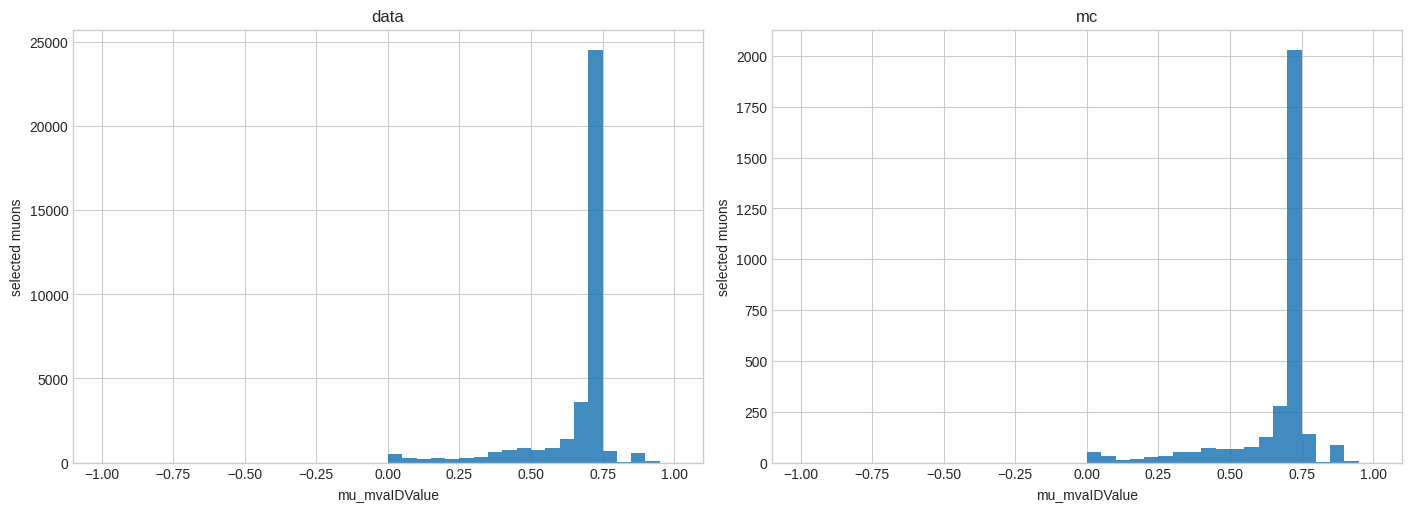

In [24]:
fig, axes = plt.subplots(1, len(sample_tables), figsize=(7 * len(sample_tables), 5), constrained_layout=True)
if len(sample_tables) == 1:
    axes = [axes]

for ax, (sample_name, tables) in zip(axes, sample_tables.items()):
    mu_df = selected_muons(tables["muons"])
    if "mu_mvaIDValue" not in mu_df.columns:
        ax.text(0.5, 0.5, "mu_mvaIDValue not available", ha="center", va="center")
        ax.set_axis_off()
        ax.set_title(sample_name)
        continue

    values = clean_mvaid_values(mu_df["mu_mvaIDValue"].astype(float)).dropna().to_numpy()
    if len(values) == 0:
        ax.text(0.5, 0.5, "No valid mvaIDValue entries", ha="center", va="center")
        ax.set_axis_off()
        ax.set_title(sample_name)
        continue

    ax.hist(values, bins=np.linspace(-1.0, 1.0, 41), alpha=0.85)
    ax.set_title(sample_name)
    ax.set_xlabel("mu_mvaIDValue")
    ax.set_ylabel("selected muons")

plt.show()


In [25]:
METHOD_FOR_MUON_ID_TABLE = "" # Examine sourceCandidatePtr method.
ID_COLUMNS_FOR_MULTIPLICITY = [
    "mu_passedCutBasedIdLoose",
    "mu_passedCutBasedIdMedium",
    "mu_passedCutBasedIdTight",
    "mu_passedCutBasedIdSoft",
    "mu_passedMvaIDwpSoft",
    "mu_passedMvaIDwpTight",
]

for sample_name, tables in sample_tables.items():
    mu_df = muon_browser_table(tables)
    count_col = f"n_{METHOD_FOR_MUON_ID_TABLE}_pass"
    if count_col not in mu_df.columns:
        print(f"\n{sample_name}: missing {count_col}, skipping multiplicity-vs-ID table")
        continue

    mu_df = mu_df.assign(
        multiplicity_category=mu_df[count_col].map(lambda value: "no-match" if value == 0 else ("unique" if value == 1 else "multi"))
    )

    print(f"\nMultiplicity vs muon ID for {sample_name} ({METHOD_FOR_MUON_ID_TABLE})")
    for id_col in existing_columns(mu_df, ID_COLUMNS_FOR_MULTIPLICITY):
        table = pd.crosstab(mu_df[id_col], mu_df["multiplicity_category"], normalize="index")
        print(id_col)
        display(table)



data: missing n__pass, skipping multiplicity-vs-ID table

mc: missing n__pass, skipping multiplicity-vs-ID table


## Zero-match and multi-match browsing with muon IDs

These cells now browse zero-match and multi-match muons for any selection in `BROWSE_SELECTIONS`, including `legacy`, `vector`, `chi2`, `dzPv`, `dzAssoc`, `pointer`, `sourcePtr`, and `pfRef`.

The driver cell returns a dictionary with `occurrences`, `occurrence`, and `candidate_view`, so you can reuse the filtered tables later in the notebook without duplicating the browsing logic.


In [26]:
pd.DataFrame.from_dict(BROWSE_SELECTIONS, orient="index")


,count_col,pass_col,final_col,winner_col,sort_metric
legacy,mu_nPassLegacyBox,legacyBoxPass,finalLegacy,mu_matchLegacyPackedIdx,deltaPRelVec
vector,mu_nPassVector,vectorPass,finalVector,mu_matchVectorPackedIdx,deltaPRelVec
chi2,mu_nPassChi2,chi2Pass,finalChi2,mu_matchChi2PackedIdx,chi2MomentumDiag
dzPv,mu_nPassDzPv,dzPvPass,finalDzPv,mu_matchDzPvPackedIdx,chi2MomentumDzSelectedPV
dzAssoc,mu_nPassDzAssoc,dzAssocPass,finalDzAssoc,mu_matchDzAssocPackedIdx,chi2MomentumDzAssocPV
pointer,mu_pointerResolvedCount,pointerMatchAny,finalPointer,mu_matchPointerPackedIdx,None
sourcePtr,mu_sourceCandidateResolvedCount,pointerMatchSource,None,None,None
pfRef,mu_pfCandidateRefResolved,pointerMatchPfRef,None,None,None


In [27]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="legacy",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=legacy, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=3


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassLegacyBox,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,17,7532136,3,3.033351,0.040620,-1.624882,0.001675,-1.808903,0.001770,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
1,369873,35,27422797,2,3.707382,0.054124,0.278048,0.000732,2.130144,0.000767,-1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
2,369873,68,62563794,2,3.592431,0.050182,1.094874,0.000732,-1.932306,0.000809,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,-99.0,0,0


,value
run,3.698730e+05
lumi,1.700000e+01
event,7.532136e+06
mu_index,3.000000e+00
mu_pt,3.033351e+00
mu_ptErr,4.062021e-02
mu_eta,-1.624882e+00
mu_etaErr,1.674732e-03
mu_phi,-1.808903e+00
mu_phiErr,1.770061e-03


,packedIndex,legacyBoxPass,finalLegacy,vectorPass,chi2Pass,dzPvPass,dzAssocPass,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,cand_pdgId,cand_charge,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,deltaPRelVec,chi2MomentumDiag,deltaDzSelectedPV,deltaDzAssocPV,chi2MomentumDzSelectedPV,chi2MomentumDzAssocPV
0,2013,0,0,0,0,0,0,1,1,0,211,1,1.393555,0.037508,-1.624928,0.001637,-1.808949,0.001874,0,6,22,0.54057,4272.740723,0.000026,0.000025,4272.740723,4272.740723


{'occurrences':       run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0  369873    17   7532136                0         3                 1  \
 1  369873    35  27422797                0         2                 1   
 2  369873    68  62563794                0         2                 1   
 
    mu_charge  mu_hasTrack  mu_trackSource     mu_pt    mu_eta    mu_phi   
 0          1            1               1  3.033351 -1.624882 -1.808903  \
 1         -1            1               1  3.707382  0.278048  2.130144   
 2          1            1               1  3.592431  1.094874 -1.932306   
 
       mu_px     mu_py     mu_pz  mu_ptErr  mu_etaErr  mu_phiErr  mu_dxyErr   
 0 -0.715455 -2.947769 -7.402723  0.040620   0.001675   0.001770   0.018347  \
 1 -1.967259  3.142383  1.044164  0.054124   0.000732   0.000767   0.003102   
 2 -1.270595 -3.360231  4.767557  0.050182   0.000732   0.000809   0.003769   
 
    mu_dzErr  mu_pxErr  mu_pyErr  mu_pzErr  mu_dzSelectedPV

In [28]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="vector",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=vector, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=3


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassVector,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,17,7532136,3,3.033351,0.040620,-1.624882,0.001675,-1.808903,0.001770,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
1,369873,35,27422797,2,3.707382,0.054124,0.278048,0.000732,2.130144,0.000767,-1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
2,369873,68,62563794,2,3.592431,0.050182,1.094874,0.000732,-1.932306,0.000809,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,-99.0,0,0


,value
run,3.698730e+05
lumi,1.700000e+01
event,7.532136e+06
mu_index,3.000000e+00
mu_pt,3.033351e+00
mu_ptErr,4.062021e-02
mu_eta,-1.624882e+00
mu_etaErr,1.674732e-03
mu_phi,-1.808903e+00
mu_phiErr,1.770061e-03


,packedIndex,vectorPass,finalVector,legacyBoxPass,chi2Pass,dzPvPass,dzAssocPass,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,cand_pdgId,cand_charge,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,deltaPRelVec,chi2MomentumDiag,deltaDzSelectedPV,deltaDzAssocPV,chi2MomentumDzSelectedPV,chi2MomentumDzAssocPV
0,2013,0,0,0,0,0,0,1,1,0,211,1,1.393555,0.037508,-1.624928,0.001637,-1.808949,0.001874,0,6,22,0.54057,4272.740723,0.000026,0.000025,4272.740723,4272.740723


{'occurrences':       run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0  369873    17   7532136                0         3                 1  \
 1  369873    35  27422797                0         2                 1   
 2  369873    68  62563794                0         2                 1   
 
    mu_charge  mu_hasTrack  mu_trackSource     mu_pt    mu_eta    mu_phi   
 0          1            1               1  3.033351 -1.624882 -1.808903  \
 1         -1            1               1  3.707382  0.278048  2.130144   
 2          1            1               1  3.592431  1.094874 -1.932306   
 
       mu_px     mu_py     mu_pz  mu_ptErr  mu_etaErr  mu_phiErr  mu_dxyErr   
 0 -0.715455 -2.947769 -7.402723  0.040620   0.001675   0.001770   0.018347  \
 1 -1.967259  3.142383  1.044164  0.054124   0.000732   0.000767   0.003102   
 2 -1.270595 -3.360231  4.767557  0.050182   0.000732   0.000809   0.003769   
 
    mu_dzErr  mu_pxErr  mu_pyErr  mu_pzErr  mu_dzSelectedPV

In [29]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="chi2",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=chi2, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=3


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassChi2,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,17,7532136,3,3.033351,0.040620,-1.624882,0.001675,-1.808903,0.001770,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
1,369873,35,27422797,2,3.707382,0.054124,0.278048,0.000732,2.130144,0.000767,-1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
2,369873,68,62563794,2,3.592431,0.050182,1.094874,0.000732,-1.932306,0.000809,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,-99.0,0,0


,value
run,3.698730e+05
lumi,1.700000e+01
event,7.532136e+06
mu_index,3.000000e+00
mu_pt,3.033351e+00
mu_ptErr,4.062021e-02
mu_eta,-1.624882e+00
mu_etaErr,1.674732e-03
mu_phi,-1.808903e+00
mu_phiErr,1.770061e-03


,packedIndex,chi2Pass,finalChi2,legacyBoxPass,vectorPass,dzPvPass,dzAssocPass,pointerMatchAny,pointerMatchSource,pointerMatchPfRef,cand_pdgId,cand_charge,cand_pt,cand_ptErr,cand_eta,cand_etaErr,cand_phi,cand_phiErr,cand_fromPV,cand_pvAssocQuality,cand_vertexRefKey,deltaPRelVec,chi2MomentumDiag,deltaDzSelectedPV,deltaDzAssocPV,chi2MomentumDzSelectedPV,chi2MomentumDzAssocPV
0,2013,0,0,0,0,0,0,1,1,0,211,1,1.393555,0.037508,-1.624928,0.001637,-1.808949,0.001874,0,6,22,0.54057,4272.740723,0.000026,0.000025,4272.740723,4272.740723


{'occurrences':       run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0  369873    17   7532136                0         3                 1  \
 1  369873    35  27422797                0         2                 1   
 2  369873    68  62563794                0         2                 1   
 
    mu_charge  mu_hasTrack  mu_trackSource     mu_pt    mu_eta    mu_phi   
 0          1            1               1  3.033351 -1.624882 -1.808903  \
 1         -1            1               1  3.707382  0.278048  2.130144   
 2          1            1               1  3.592431  1.094874 -1.932306   
 
       mu_px     mu_py     mu_pz  mu_ptErr  mu_etaErr  mu_phiErr  mu_dxyErr   
 0 -0.715455 -2.947769 -7.402723  0.040620   0.001675   0.001770   0.018347  \
 1 -1.967259  3.142383  1.044164  0.054124   0.000732   0.000767   0.003102   
 2 -1.270595 -3.360231  4.767557  0.050182   0.000732   0.000809   0.003769   
 
    mu_dzErr  mu_pxErr  mu_pyErr  mu_pzErr  mu_dzSelectedPV

In [30]:
browse_match_occurrences(
    sample_tables,
    sample_name='data',
    selection_name='sourcePtr',
    kind='zero',
    muon_id_wp='mu_passedCutBasedIdSoft',
    selected_only=True,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)

sample=data, selection=sourcePtr, kind=zero, selected_only=True, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=2


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_sourceCandidateResolvedCount,mu_pointerResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,35,27422797,2,3.707382,0.054124,0.278048,0.000732,2.130144,0.000767,-1,0,0,0,0,0,0,0,0,0,0,0,1,0,-99.0,0,0
1,369873,68,62563794,2,3.592431,0.050182,1.094874,0.000732,-1.932306,0.000809,1,0,0,0,0,0,0,0,0,0,0,0,1,1,-99.0,0,0


,value
run,3.698730e+05
lumi,3.500000e+01
event,2.742280e+07
mu_index,2.000000e+00
mu_pt,3.707382e+00
mu_ptErr,5.412352e-02
mu_eta,2.780479e-01
mu_etaErr,7.317462e-04
mu_phi,2.130144e+00
mu_phiErr,7.668633e-04


No retained MuonCandMatch rows were written for this muon.


{'occurrences':       run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0  369873    35  27422797                0         2                 1  \
 1  369873    68  62563794                0         2                 1   
 
    mu_charge  mu_hasTrack  mu_trackSource     mu_pt    mu_eta    mu_phi   
 0         -1            1               1  3.707382  0.278048  2.130144  \
 1          1            1               1  3.592431  1.094874 -1.932306   
 
       mu_px     mu_py     mu_pz  mu_ptErr  mu_etaErr  mu_phiErr  mu_dxyErr   
 0 -1.967259  3.142383  1.044164  0.054124   0.000732   0.000767   0.003102  \
 1 -1.270595 -3.360231  4.767557  0.050182   0.000732   0.000809   0.003769   
 
    mu_dzErr  mu_pxErr  mu_pyErr  mu_pzErr  mu_dzSelectedPV  mu_dxySelectedPV   
 0  0.003438  0.029792  0.045276  0.015456         0.001554         -0.005287  \
 1  0.005916  0.019051  0.046516  0.066525         6.886269         -0.002523   
 
    mu_passedCutBasedIdLoose  mu_passedCutBa

So in data, only 3 soft muons fail to match any candidate by legacy, momentum vector difference, or momentum chi2. However, one candidate was rescued by the `sourceCandidatePtr` method, with $\eta$ and $\phi$ matching the muon. This shows a slight edge of the pointer-based method in recovering good matches that fail the other methods.

A next-step is validating with MC samples.

In [31]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="legacy",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=legacy, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=0


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassLegacyBox,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight


{'occurrences': Empty DataFrame
 Columns: [run, lumi, event, selectedPVIndex, mu_index, mu_passSelection, mu_charge, mu_hasTrack, mu_trackSource, mu_pt, mu_eta, mu_phi, mu_px, mu_py, mu_pz, mu_ptErr, mu_etaErr, mu_phiErr, mu_dxyErr, mu_dzErr, mu_pxErr, mu_pyErr, mu_pzErr, mu_dzSelectedPV, mu_dxySelectedPV, mu_passedCutBasedIdLoose, mu_passedCutBasedIdMedium, mu_passedCutBasedIdMediumPrompt, mu_passedCutBasedIdTight, mu_passedCutBasedIdGlobalHighPt, mu_passedCutBasedIdTrkHighPt, mu_passedCutBasedIdSoft, mu_passedMvaIDwpSoft, mu_mvaIDValue, mu_passedMvaIDwpMedium, mu_passedMvaIDwpTight, mu_nSourceCandidatePtrs, mu_hasPfCandidateRef, mu_pfCandidateRefResolved, mu_sourceCandidateResolvedCount, mu_pointerResolvedCount, mu_pointerMultiplicityAnomaly, mu_matchLegacyPackedIdx, mu_matchVectorPackedIdx, mu_matchChi2PackedIdx, mu_matchDzPvPackedIdx, mu_matchDzAssocPackedIdx, mu_matchPointerPackedIdx, mu_nPassLegacyBox, mu_nPassVector, mu_nPassChi2, mu_nPassDzPv, mu_nPassDzAssoc]
 Index: [],
 'occ

In [32]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="vector",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=vector, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=0


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassVector,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight


{'occurrences': Empty DataFrame
 Columns: [run, lumi, event, selectedPVIndex, mu_index, mu_passSelection, mu_charge, mu_hasTrack, mu_trackSource, mu_pt, mu_eta, mu_phi, mu_px, mu_py, mu_pz, mu_ptErr, mu_etaErr, mu_phiErr, mu_dxyErr, mu_dzErr, mu_pxErr, mu_pyErr, mu_pzErr, mu_dzSelectedPV, mu_dxySelectedPV, mu_passedCutBasedIdLoose, mu_passedCutBasedIdMedium, mu_passedCutBasedIdMediumPrompt, mu_passedCutBasedIdTight, mu_passedCutBasedIdGlobalHighPt, mu_passedCutBasedIdTrkHighPt, mu_passedCutBasedIdSoft, mu_passedMvaIDwpSoft, mu_mvaIDValue, mu_passedMvaIDwpMedium, mu_passedMvaIDwpTight, mu_nSourceCandidatePtrs, mu_hasPfCandidateRef, mu_pfCandidateRefResolved, mu_sourceCandidateResolvedCount, mu_pointerResolvedCount, mu_pointerMultiplicityAnomaly, mu_matchLegacyPackedIdx, mu_matchVectorPackedIdx, mu_matchChi2PackedIdx, mu_matchDzPvPackedIdx, mu_matchDzAssocPackedIdx, mu_matchPointerPackedIdx, mu_nPassLegacyBox, mu_nPassVector, mu_nPassChi2, mu_nPassDzPv, mu_nPassDzAssoc]
 Index: [],
 'occ

In [33]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="chi2",
    kind="zero",
    muon_id_wp="mu_passedCutBasedIdSoft",
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=chi2, kind=zero, selected_only=False, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=0


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassChi2,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight


{'occurrences': Empty DataFrame
 Columns: [run, lumi, event, selectedPVIndex, mu_index, mu_passSelection, mu_charge, mu_hasTrack, mu_trackSource, mu_pt, mu_eta, mu_phi, mu_px, mu_py, mu_pz, mu_ptErr, mu_etaErr, mu_phiErr, mu_dxyErr, mu_dzErr, mu_pxErr, mu_pyErr, mu_pzErr, mu_dzSelectedPV, mu_dxySelectedPV, mu_passedCutBasedIdLoose, mu_passedCutBasedIdMedium, mu_passedCutBasedIdMediumPrompt, mu_passedCutBasedIdTight, mu_passedCutBasedIdGlobalHighPt, mu_passedCutBasedIdTrkHighPt, mu_passedCutBasedIdSoft, mu_passedMvaIDwpSoft, mu_mvaIDValue, mu_passedMvaIDwpMedium, mu_passedMvaIDwpTight, mu_nSourceCandidatePtrs, mu_hasPfCandidateRef, mu_pfCandidateRefResolved, mu_sourceCandidateResolvedCount, mu_pointerResolvedCount, mu_pointerMultiplicityAnomaly, mu_matchLegacyPackedIdx, mu_matchVectorPackedIdx, mu_matchChi2PackedIdx, mu_matchDzPvPackedIdx, mu_matchDzAssocPackedIdx, mu_matchPointerPackedIdx, mu_nPassLegacyBox, mu_nPassVector, mu_nPassChi2, mu_nPassDzPv, mu_nPassDzAssoc]
 Index: [],
 'occ

In [34]:
browse_match_occurrences(
    sample_tables,
    sample_name='mc',
    selection_name='sourcePtr',
    kind='zero',
    muon_id_wp='mu_passedCutBasedIdSoft',
    selected_only=True,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)

sample=mc, selection=sourcePtr, kind=zero, selected_only=True, muon_id_wp=mu_passedCutBasedIdSoft, n_occurrences=0


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_sourceCandidateResolvedCount,mu_pointerResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight


{'occurrences': Empty DataFrame
 Columns: [run, lumi, event, selectedPVIndex, mu_index, mu_passSelection, mu_charge, mu_hasTrack, mu_trackSource, mu_pt, mu_eta, mu_phi, mu_px, mu_py, mu_pz, mu_ptErr, mu_etaErr, mu_phiErr, mu_dxyErr, mu_dzErr, mu_pxErr, mu_pyErr, mu_pzErr, mu_dzSelectedPV, mu_dxySelectedPV, mu_passedCutBasedIdLoose, mu_passedCutBasedIdMedium, mu_passedCutBasedIdMediumPrompt, mu_passedCutBasedIdTight, mu_passedCutBasedIdGlobalHighPt, mu_passedCutBasedIdTrkHighPt, mu_passedCutBasedIdSoft, mu_passedMvaIDwpSoft, mu_mvaIDValue, mu_passedMvaIDwpMedium, mu_passedMvaIDwpTight, mu_nSourceCandidatePtrs, mu_hasPfCandidateRef, mu_pfCandidateRefResolved, mu_sourceCandidateResolvedCount, mu_pointerResolvedCount, mu_pointerMultiplicityAnomaly, mu_matchLegacyPackedIdx, mu_matchVectorPackedIdx, mu_matchChi2PackedIdx, mu_matchDzPvPackedIdx, mu_matchDzAssocPackedIdx, mu_matchPointerPackedIdx, mu_nPassLegacyBox, mu_nPassVector, mu_nPassChi2, mu_nPassDzPv, mu_nPassDzAssoc]
 Index: [],
 'occ

At the current statistics, all methods tested did not show 'no-match' soft muons. We could need adding a bit more MC to see some zero-match cases and study them in detail.

What if not demanding the muon ID WP?

In [35]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="legacy",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=legacy, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=1678


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassLegacyBox,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,1,7648,1,4.628965,0.181178,-2.282648,0.000943,-1.892230,0.001234,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,369873,1,12264,1,6.129717,0.147379,-0.545277,0.000511,1.286402,0.000726,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,369873,1,13008,0,25.369843,2.814367,-1.068314,0.008244,-0.242830,0.007785,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,369873,1,41648,2,9.552628,0.266073,-1.566452,0.050888,-1.278986,0.004860,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,369873,1,58080,2,3.188660,0.061800,-1.630053,0.000914,-1.635625,0.001149,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,369873,1,70096,0,16.811876,2.216717,0.482643,0.010925,2.340535,0.018945,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,369873,1,71232,0,23.946264,0.459402,-1.270800,0.001460,-1.090548,0.000405,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,369873,1,79496,1,4.502418,0.290679,-0.515196,0.036374,-1.129922,0.059055,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,369873,1,97464,0,7.347986,0.625709,0.159964,0.016864,1.598818,0.027251,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,369873,1,107680,0,24.437618,7.868806,-1.755781,0.000318,-0.529862,0.001538,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,369873.000000
lumi,1.000000
event,7648.000000
mu_index,1.000000
mu_pt,4.628965
mu_ptErr,0.181178
mu_eta,-2.282648
mu_etaErr,0.000943
mu_phi,-1.892230
mu_phiErr,0.001234


No retained MuonCandMatch rows were written for this muon.


{'occurrences':          run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0     369873     1      7648                0         1                 1  \
 1     369873     1     12264                0         1                 1   
 2     369873     1     13008                0         0                 1   
 3     369873     1     41648                0         2                 1   
 4     369873     1     58080                0         2                 1   
 ...      ...   ...       ...              ...       ...               ...   
 1673  369873    73  67734472                0         5                 1   
 1674  369873    73  67826463                0         0                 1   
 1675  369873    73  67833828                0         1                 1   
 1676  369873    73  67854999                0         1                 1   
 1677  369873    73  67864969                0         1                 1   
 
       mu_charge  mu_hasTrack  mu_trackSource  

In [36]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="vector",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=vector, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=1763


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassVector,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,1,7648,1,4.628965,0.181178,-2.282648,0.000943,-1.892230,0.001234,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,369873,1,12264,1,6.129717,0.147379,-0.545277,0.000511,1.286402,0.000726,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,369873,1,13008,0,25.369843,2.814367,-1.068314,0.008244,-0.242830,0.007785,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,369873,1,41648,2,9.552628,0.266073,-1.566452,0.050888,-1.278986,0.004860,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,369873,1,58080,2,3.188660,0.061800,-1.630053,0.000914,-1.635625,0.001149,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,369873,1,70096,0,16.811876,2.216717,0.482643,0.010925,2.340535,0.018945,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,369873,1,71232,0,23.946264,0.459402,-1.270800,0.001460,-1.090548,0.000405,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,369873,1,79496,1,4.502418,0.290679,-0.515196,0.036374,-1.129922,0.059055,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,369873,1,97464,0,7.347986,0.625709,0.159964,0.016864,1.598818,0.027251,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,369873,1,107680,0,24.437618,7.868806,-1.755781,0.000318,-0.529862,0.001538,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,369873.000000
lumi,1.000000
event,7648.000000
mu_index,1.000000
mu_pt,4.628965
mu_ptErr,0.181178
mu_eta,-2.282648
mu_etaErr,0.000943
mu_phi,-1.892230
mu_phiErr,0.001234


No retained MuonCandMatch rows were written for this muon.


{'occurrences':          run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0     369873     1      7648                0         1                 1  \
 1     369873     1     12264                0         1                 1   
 2     369873     1     13008                0         0                 1   
 3     369873     1     41648                0         2                 1   
 4     369873     1     58080                0         2                 1   
 ...      ...   ...       ...              ...       ...               ...   
 1758  369873    73  67734472                0         5                 1   
 1759  369873    73  67826463                0         0                 1   
 1760  369873    73  67833828                0         1                 1   
 1761  369873    73  67854999                0         1                 1   
 1762  369873    73  67864969                0         1                 1   
 
       mu_charge  mu_hasTrack  mu_trackSource  

In [37]:
browse_match_occurrences(
    sample_tables,
    sample_name="data",
    selection_name="chi2",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=data, selection=chi2, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=1528


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassChi2,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,1,7648,1,4.628965,0.181178,-2.282648,0.000943,-1.892230,0.001234,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,369873,1,12264,1,6.129717,0.147379,-0.545277,0.000511,1.286402,0.000726,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,369873,1,13008,0,25.369843,2.814367,-1.068314,0.008244,-0.242830,0.007785,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,369873,1,41648,2,9.552628,0.266073,-1.566452,0.050888,-1.278986,0.004860,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,369873,1,58080,2,3.188660,0.061800,-1.630053,0.000914,-1.635625,0.001149,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,369873,1,70096,0,16.811876,2.216717,0.482643,0.010925,2.340535,0.018945,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,369873,1,71232,0,23.946264,0.459402,-1.270800,0.001460,-1.090548,0.000405,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,369873,1,79496,1,4.502418,0.290679,-0.515196,0.036374,-1.129922,0.059055,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,369873,1,97464,0,7.347986,0.625709,0.159964,0.016864,1.598818,0.027251,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,369873,1,162288,0,10.767175,1.263649,-1.072676,0.011985,-2.726446,0.019629,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,369873.000000
lumi,1.000000
event,7648.000000
mu_index,1.000000
mu_pt,4.628965
mu_ptErr,0.181178
mu_eta,-2.282648
mu_etaErr,0.000943
mu_phi,-1.892230
mu_phiErr,0.001234


No retained MuonCandMatch rows were written for this muon.


{'occurrences':          run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0     369873     1      7648                0         1                 1  \
 1     369873     1     12264                0         1                 1   
 2     369873     1     13008                0         0                 1   
 3     369873     1     41648                0         2                 1   
 4     369873     1     58080                0         2                 1   
 ...      ...   ...       ...              ...       ...               ...   
 1523  369873    73  67734472                0         5                 1   
 1524  369873    73  67826463                0         0                 1   
 1525  369873    73  67833828                0         1                 1   
 1526  369873    73  67854999                0         1                 1   
 1527  369873    73  67864969                0         1                 1   
 
       mu_charge  mu_hasTrack  mu_trackSource  

In [38]:
browse_match_occurrences(
    sample_tables,
    sample_name='data',
    selection_name='sourcePtr',
    kind='zero',
    muon_id_wp=None,
    selected_only=True,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)

sample=data, selection=sourcePtr, kind=zero, selected_only=True, muon_id_wp=None, n_occurrences=1744


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_sourceCandidateResolvedCount,mu_pointerResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,369873,1,7648,1,4.628965,0.181178,-2.282648,0.000943,-1.892230,0.001234,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,369873,1,12264,1,6.129717,0.147379,-0.545277,0.000511,1.286402,0.000726,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,369873,1,13008,0,25.369843,2.814367,-1.068314,0.008244,-0.242830,0.007785,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,369873,1,41648,2,9.552628,0.266073,-1.566452,0.050888,-1.278986,0.004860,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,369873,1,58080,2,3.188660,0.061800,-1.630053,0.000914,-1.635625,0.001149,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,369873,1,70096,0,16.811876,2.216717,0.482643,0.010925,2.340535,0.018945,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,369873,1,71232,0,23.946264,0.459402,-1.270800,0.001460,-1.090548,0.000405,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,369873,1,79496,1,4.502418,0.290679,-0.515196,0.036374,-1.129922,0.059055,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,369873,1,97464,0,7.347986,0.625709,0.159964,0.016864,1.598818,0.027251,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,369873,1,107680,0,24.437618,7.868806,-1.755781,0.000318,-0.529862,0.001538,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,369873.000000
lumi,1.000000
event,7648.000000
mu_index,1.000000
mu_pt,4.628965
mu_ptErr,0.181178
mu_eta,-2.282648
mu_etaErr,0.000943
mu_phi,-1.892230
mu_phiErr,0.001234


No retained MuonCandMatch rows were written for this muon.


{'occurrences':          run  lumi     event  selectedPVIndex  mu_index  mu_passSelection   
 0     369873     1      7648                0         1                 1  \
 1     369873     1     12264                0         1                 1   
 2     369873     1     13008                0         0                 1   
 3     369873     1     41648                0         2                 1   
 4     369873     1     58080                0         2                 1   
 ...      ...   ...       ...              ...       ...               ...   
 1739  369873    73  67734472                0         5                 1   
 1740  369873    73  67826463                0         0                 1   
 1741  369873    73  67833828                0         1                 1   
 1742  369873    73  67854999                0         1                 1   
 1743  369873    73  67864969                0         1                 1   
 
       mu_charge  mu_hasTrack  mu_trackSource  

Momentum chi2 matching seems to be giving less zero-matches than the other methods. Yet the implication of this result could be limited, since the zero-match muons here mostly fail at the soft ID WP, and these muons are to be discarded in the final analysis anyway.

A good next-step is increasing the statistics, adding more collision data for this part.

Before that, we can check MC samples if similar behaviour is observed.

In [39]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="legacy",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=legacy, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=278


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassLegacyBox,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,1,1,5,2,5.117325,0.258925,-0.010108,0.020756,0.180877,0.031329,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,1,1,17,1,7.942730,0.620547,-1.066572,0.008807,1.816517,0.006743,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,1,1,26,3,3.011779,0.157721,2.002892,0.001224,1.874260,0.001731,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,1,1,31,3,4.624826,0.245175,0.983136,0.021847,-0.650428,0.028011,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,1,1,35,1,5.964448,0.241009,-0.000173,0.030684,-1.259774,0.021234,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,1,1,39,2,7.998631,0.137551,1.033053,0.000629,1.383598,0.000629,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,1,1,39,3,7.730911,0.492955,0.826191,0.015074,-2.883510,0.016324,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,1,1,40,3,4.635373,0.229068,-0.071735,0.028545,-2.292500,0.027790,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,1,1,44,1,12.007483,17.872906,-2.053500,0.048514,0.105637,0.175871,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,1,1,46,0,14.076769,5.472035,2.219539,0.074120,1.801988,0.019184,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,1.000000
lumi,1.000000
event,5.000000
mu_index,2.000000
mu_pt,5.117325
mu_ptErr,0.258925
mu_eta,-0.010108
mu_etaErr,0.020756
mu_phi,0.180877
mu_phiErr,0.031329


No retained MuonCandMatch rows were written for this muon.


{'occurrences':      run  lumi  event  selectedPVIndex  mu_index  mu_passSelection  mu_charge   
 0      1     1      5                0         2                 1          1  \
 1      1     1     17                0         1                 1          1   
 2      1     1     26                0         3                 1         -1   
 3      1     1     31                0         3                 1         -1   
 4      1     1     35                0         1                 1          1   
 ..   ...   ...    ...              ...       ...               ...        ...   
 273    1     1    989                0         3                 1          1   
 274    1     1    996                0         4                 1          1   
 275    1     1    996                0         5                 1         -1   
 276    1     1    996                0         6                 1         -1   
 277    1     1    999                0         0                 1         -1   
 

In [40]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="vector",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=vector, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=277


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassVector,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,1,1,5,2,5.117325,0.258925,-0.010108,0.020756,0.180877,0.031329,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,1,1,17,1,7.942730,0.620547,-1.066572,0.008807,1.816517,0.006743,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,1,1,26,3,3.011779,0.157721,2.002892,0.001224,1.874260,0.001731,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,1,1,31,3,4.624826,0.245175,0.983136,0.021847,-0.650428,0.028011,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,1,1,35,1,5.964448,0.241009,-0.000173,0.030684,-1.259774,0.021234,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,1,1,39,2,7.998631,0.137551,1.033053,0.000629,1.383598,0.000629,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,1,1,39,3,7.730911,0.492955,0.826191,0.015074,-2.883510,0.016324,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,1,1,40,3,4.635373,0.229068,-0.071735,0.028545,-2.292500,0.027790,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,1,1,44,1,12.007483,17.872906,-2.053500,0.048514,0.105637,0.175871,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,1,1,46,0,14.076769,5.472035,2.219539,0.074120,1.801988,0.019184,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,1.000000
lumi,1.000000
event,5.000000
mu_index,2.000000
mu_pt,5.117325
mu_ptErr,0.258925
mu_eta,-0.010108
mu_etaErr,0.020756
mu_phi,0.180877
mu_phiErr,0.031329


No retained MuonCandMatch rows were written for this muon.


{'occurrences':      run  lumi  event  selectedPVIndex  mu_index  mu_passSelection  mu_charge   
 0      1     1      5                0         2                 1          1  \
 1      1     1     17                0         1                 1          1   
 2      1     1     26                0         3                 1         -1   
 3      1     1     31                0         3                 1         -1   
 4      1     1     35                0         1                 1          1   
 ..   ...   ...    ...              ...       ...               ...        ...   
 272    1     1    989                0         3                 1          1   
 273    1     1    996                0         4                 1          1   
 274    1     1    996                0         5                 1         -1   
 275    1     1    996                0         6                 1         -1   
 276    1     1    999                0         0                 1         -1   
 

In [41]:
browse_match_occurrences(
    sample_tables,
    sample_name="mc",
    selection_name="chi2",
    kind="zero",
    muon_id_wp=None,
    selected_only=False,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)


sample=mc, selection=chi2, kind=zero, selected_only=False, muon_id_wp=None, n_occurrences=238


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_nPassChi2,mu_pointerResolvedCount,mu_sourceCandidateResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,1,1,5,2,5.117325,0.258925,-0.010108,0.020756,0.180877,0.031329,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,1,1,17,1,7.942730,0.620547,-1.066572,0.008807,1.816517,0.006743,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,1,1,26,3,3.011779,0.157721,2.002892,0.001224,1.874260,0.001731,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,1,1,31,3,4.624826,0.245175,0.983136,0.021847,-0.650428,0.028011,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,1,1,35,1,5.964448,0.241009,-0.000173,0.030684,-1.259774,0.021234,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,1,1,39,2,7.998631,0.137551,1.033053,0.000629,1.383598,0.000629,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,1,1,39,3,7.730911,0.492955,0.826191,0.015074,-2.883510,0.016324,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,1,1,50,3,5.897751,0.116902,1.244643,0.003110,-2.889761,0.002130,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,1,1,53,3,5.938892,0.389743,0.170515,0.019766,-0.793664,0.022552,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,1,1,59,2,6.206411,0.357260,-0.584455,0.024113,-2.769263,0.020687,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,1.000000
lumi,1.000000
event,5.000000
mu_index,2.000000
mu_pt,5.117325
mu_ptErr,0.258925
mu_eta,-0.010108
mu_etaErr,0.020756
mu_phi,0.180877
mu_phiErr,0.031329


No retained MuonCandMatch rows were written for this muon.


{'occurrences':      run  lumi  event  selectedPVIndex  mu_index  mu_passSelection  mu_charge   
 0      1     1      5                0         2                 1          1  \
 1      1     1     17                0         1                 1          1   
 2      1     1     26                0         3                 1         -1   
 3      1     1     31                0         3                 1         -1   
 4      1     1     35                0         1                 1          1   
 ..   ...   ...    ...              ...       ...               ...        ...   
 233    1     1    989                0         3                 1          1   
 234    1     1    996                0         4                 1          1   
 235    1     1    996                0         5                 1         -1   
 236    1     1    996                0         6                 1         -1   
 237    1     1    999                0         0                 1         -1   
 

In [42]:
browse_match_occurrences(
    sample_tables,
    sample_name='mc',
    selection_name='sourcePtr',
    kind='zero',
    muon_id_wp=None,
    selected_only=True,
    max_rows=10,
    inspect_index=0,
    pass_only=False,
)

sample=mc, selection=sourcePtr, kind=zero, selected_only=True, muon_id_wp=None, n_occurrences=275


,run,lumi,event,mu_index,mu_pt,mu_ptErr,mu_eta,mu_etaErr,mu_phi,mu_phiErr,mu_charge,selectedPVIndex,mu_sourceCandidateResolvedCount,mu_pointerResolvedCount,mu_pfCandidateRefResolved,mu_pointerMultiplicityAnomaly,mu_passedCutBasedIdLoose,mu_passedCutBasedIdMedium,mu_passedCutBasedIdMediumPrompt,mu_passedCutBasedIdTight,mu_passedCutBasedIdGlobalHighPt,mu_passedCutBasedIdTrkHighPt,mu_passedCutBasedIdSoft,mu_passedMvaIDwpSoft,mu_mvaIDValue,mu_passedMvaIDwpMedium,mu_passedMvaIDwpTight
0,1,1,5,2,5.117325,0.258925,-0.010108,0.020756,0.180877,0.031329,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
1,1,1,17,1,7.942730,0.620547,-1.066572,0.008807,1.816517,0.006743,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
2,1,1,26,3,3.011779,0.157721,2.002892,0.001224,1.874260,0.001731,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
3,1,1,31,3,4.624826,0.245175,0.983136,0.021847,-0.650428,0.028011,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
4,1,1,35,1,5.964448,0.241009,-0.000173,0.030684,-1.259774,0.021234,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
5,1,1,39,2,7.998631,0.137551,1.033053,0.000629,1.383598,0.000629,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
6,1,1,39,3,7.730911,0.492955,0.826191,0.015074,-2.883510,0.016324,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
7,1,1,40,3,4.635373,0.229068,-0.071735,0.028545,-2.292500,0.027790,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
8,1,1,44,1,12.007483,17.872906,-2.053500,0.048514,0.105637,0.175871,1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0
9,1,1,46,0,14.076769,5.472035,2.219539,0.074120,1.801988,0.019184,-1,0,0,0,0,0,0,0,0,0,0,0,0,0,-99.0,0,0


,value
run,1.000000
lumi,1.000000
event,5.000000
mu_index,2.000000
mu_pt,5.117325
mu_ptErr,0.258925
mu_eta,-0.010108
mu_etaErr,0.020756
mu_phi,0.180877
mu_phiErr,0.031329


No retained MuonCandMatch rows were written for this muon.


{'occurrences':      run  lumi  event  selectedPVIndex  mu_index  mu_passSelection  mu_charge   
 0      1     1      5                0         2                 1          1  \
 1      1     1     17                0         1                 1          1   
 2      1     1     26                0         3                 1         -1   
 3      1     1     31                0         3                 1         -1   
 4      1     1     35                0         1                 1          1   
 ..   ...   ...    ...              ...       ...               ...        ...   
 270    1     1    989                0         3                 1          1   
 271    1     1    996                0         4                 1          1   
 272    1     1    996                0         5                 1         -1   
 273    1     1    996                0         6                 1         -1   
 274    1     1    999                0         0                 1         -1   
 

MC results are consistent with data, showing, when not requiring soft muon criterion, momentum chi2 gives least zero-matches. Still, this may not matter given the soft muon criterion to be applied in the final analysis.

A short conclusion for now will be that the pointer-based method shows a slight edge in recovering good matches to the soft muons that fail the other methods. Will need more data and MC statistics to fully validate.

One reminder here: soft muons account for more than $87\%$ of the total reconstructed muons in the current data and MC samples, while the zero-match soft muons are seen only at the fraction of $(2\sim 3)/ (87\% \times 61706) \sim 10^{-4}$. So the zero-match soft muons are very rare, and the difference of a few zero-matches between methods may not be significant for the final analysis.